In [63]:
%matplotlib notebook
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy

<IPython.core.display.Javascript object>


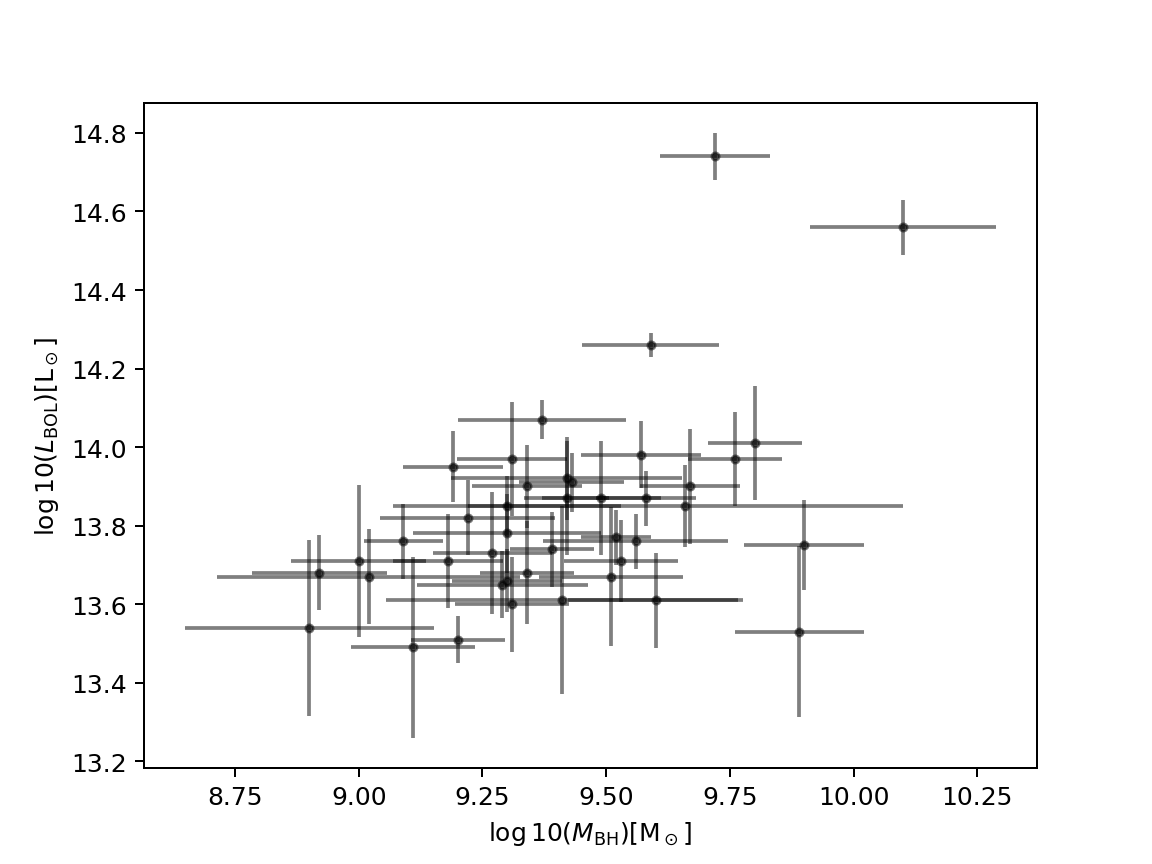

<ErrorbarContainer object of 3 artists>

In [64]:
# Problem 1 
# Part A
d = np.loadtxt("LbolMbh2.dat",unpack=True)
lL = d[0]
lM = d[1]
slL = d[2]
slM = d[3]

fig, ax = plt.subplots()

ax.set_xlabel(r"$\log10(M_{\rm BH}) [{\rm M_\odot}]$")
ax.set_ylabel(r"$\log10(L_{\rm BOL}) [{\rm L_\odot}]$")

ax.errorbar(lM,lL,slL,slM,"k.",alpha = 0.5)

In [68]:
from timeit import default_timer as timer # time all methods

Mcen = np.mean(lM)

def ifun2(L,M,t,Li,Mi,dLi,dMi):
    '''
    Return p(lL,lM) function for the given model parametes times Gaussian for one data point
    Inputs: integration variables lL=log10(L), lM=log10(M)
            vector of parameters t
            data point: log10(L_i), log10(M_i), and their errors.
    '''
    Lfit = t[0]*(M-Mcen) + t[1]
    v = np.exp(- (L - Lfit) ** 2 / (2 * (t[2] ** 2)))
    v2 = np.exp(- ((M - Mi) **2) / (2 * (dMi ** 2)))
    v3 = np.exp(- ((L - Li) **2) / (2 * (dLi ** 2)))
    return v * v2 * v3

#
# log-likelihood
#
                
def llfun2(t, loud = True):
    '''
    Return -log(L) where L is the likelihood
    Inputs: vector of parameters t
            optional argument that toggles printing (useful for debugging)
    '''
    
    start_time = timer()
    ret = 0
    for i in range(len(lL)):
        pie = (2*np.pi)**(3/2)
        C = 1/(pie* t[2]*slL[i]*slM[i])
        lL1 = lL[i] - 5*slL[i]
        lL2 = lL[i] + 5*slL[i]
        lM1 = lM[i] - 5*slM[i]
        lM2 = lM[i] + 5*slM[i]
        v = scipy.integrate.dblquad(ifun2,lM1,lM2,lL1,lL2,args=(t,lL[i],lM[i],slL[i],slM[i]) )
        if(v[0] > 0): 
            ret -= np.log(C*v[0]) 
    if(loud):
        print(t, "ll=%g time=%g"%(ret,timer()-start_time))
    return ret
t0 = [1, 13.4, 1]
print(llfun2(t0))

[1, 13.4, 1] ll=44.4253 time=1.69347
44.42533354155744


In [69]:
start_time = timer()
bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1,10,0.1])
bounds0.ub = np.array([ 2,20,3])

t0 = [ 0.49248683, 13.84313121,  0.18631161]
# [ 0.49248683 13.84313121  0.18631161] ll=-3.51221 time=1.10566
# optimization time=121.735
res = scipy.optimize.minimize(llfun2,t0, bounds = bounds0)

print("optimization time=%g"%(timer()-start_time))

[ 0.49248683 13.84313121  0.18631161] ll=-3.51221 time=1.8035
[ 0.49248684 13.84313121  0.18631161] ll=-3.51221 time=1.31332
[ 0.49248683 13.84313122  0.18631161] ll=-3.51221 time=1.15104


KeyboardInterrupt: 

In [26]:
#Part C
print(res.x,res.fun)
lMp = np.array([8.75,10.25])
ax.plot(lMp,res.x[0] *(lMp-Mcen) + res.x[1],"r-")

[ 0.49248683 13.84313121  0.1863116 ] -3.512214618073041


In [37]:
'''
Part D
Let’s now estimate errors on the intrinsic scatter. Following PS5#3G, sample f(t2) with
20-30 values for t2 between 0.25 × t∗2 and 1.75 × t∗2, marginalizing over t0 and t1 every time
(recall PS5#3F) and plot the p-value for t2 vs t2. Note: this may take many minutes to
compute, but it should not be anything even remotely close to the computational complexity
of the final project
'''

def ifun(L,M,t,t2,Li,Mi,dLi,dMi):
    Lfit = t[0]*(M-Mcen) + t[1]
    v = np.exp(- (L - Lfit) ** 2 / (2 * (t2 ** 2)))
    v2 = np.exp(- ((M - Mi) **2) / (2 * (dMi ** 2)))
    v3 = np.exp(- ((L - Li) **2) / (2 * (dLi ** 2)))
    return v * v2 * v3             
def llfun(t,t2):  
    ret = 0
    for i in range(len(lL)):
        pie = (2*np.pi)**(3/2)
        C = 1/(pie* t2*slL[i]*slM[i])
        lL1 = lL[i] - 5*slL[i]
        lL2 = lL[i] + 5*slL[i]
        lM1 = lM[i] - 5*slM[i]
        lM2 = lM[i] + 5*slM[i]
        v = scipy.integrate.dblquad(ifun,lM1,lM2,lL1,lL2,args=(t,t2,lL[i],lM[i],slL[i],slM[i]) )
        if(v[0] > 0): 
            ret -= np.log(C*v[0]) 
    print(t,ret)
    return ret

n = 20
tvals = np.zeros((n+1,n+1))
t1vals = np.zeros((n+1,n+1))
pvals = np.zeros((n,n))
tv = [0]
t = [res.x[0],res.x[1]]
x = np.linspace(0.25 *res.x[2], 1.75*res.x[2], num = n)
for i1 in range(n):
    for i0 in range(n):
        l =  llfun(t, x[i0])
        if l< 0:
            l = -1*l
        dll = -2*np.log(l) + 2*np.log(-1*res.fun)
        print('2 Param Min', l,'GLobal LL Min',res.fun)
        print(dll)
        d = -1*dll
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(d, 2)



[0.0465779  0.06128671 0.07599552 0.09070433 0.10541314 0.12012195
 0.13483076 0.14953957 0.16424838 0.17895719 0.193666   0.20837481
 0.22308363 0.23779244 0.25250125 0.26721006 0.28191887 0.29662768
 0.31133649 0.3260453 ]
[0.49248682921090586, 13.843131211612496] 2.2265967959046784
[0.49248682921090586, 13.843131211612496] 4.060980098914795
[0.49248682921090586, 13.843131211612496] 3.121560096427645
[0.49248682921090586, 13.843131211612496] 2.48693374299812
[0.49248682921090586, 13.843131211612496] 1.6195408338568715
[0.49248682921090586, 13.843131211612496] 3.346422858817462
[0.49248682921090586, 13.843131211612496] 3.954721814907994
[0.49248682921090586, 13.843131211612496] 2.916782389364946
[0.49248682921090586, 13.843131211612496] 2.791653821964966
[0.49248682921090586, 13.843131211612496] 2.3908601179664846
[0.49248682921090586, 13.843131211612496] 3.6051281209939505
[0.49248682921090586, 13.843131211612496] 2.495279003337962
[0.49248682921090586, 13.843131211612496] 1.61016559

[0.49248682921090586, 13.843131211612496] 3.2712847303820816
[0.49248682921090586, 13.843131211612496] 2.4235831280033597
[0.49248682921090586, 13.843131211612496] 1.8322536877506166
[0.49248682921090586, 13.843131211612496] 1.048856151407548
[0.49248682921090586, 13.843131211612496] 1.6658879193602079
[0.49248682921090586, 13.843131211612496] 1.8654245721797444
[0.49248682921090586, 13.843131211612496] 0.9599694755647681
[0.49248682921090586, 13.843131211612496] 0.7545333049527685
[0.49248682921090586, 13.843131211612496] 0.30458562538421513
[0.49248682921090586, 13.843131211612496] 1.2006239911998562
[0.49248682921090586, 13.843131211612496] 0.23661283626485496
[0.49248682921090586, 13.843131211612496] -0.5476399258160369
[0.49248682921090586, 13.843131211612496] -1.1982748167966655
[0.49248682921090586, 13.843131211612496] -1.9051188726930324
[0.49248682921090586, 13.843131211612496] -2.205581305320016
[0.49248682921090586, 13.843131211612496] -2.181537434677974
[0.49248682921090586

[0.49248682921090586, 13.843131211612496] 0.00628451029636834
[0.49248682921090586, 13.843131211612496] -0.23108457153862397
[0.49248682921090586, 13.843131211612496] -0.6645632003926829
[0.49248682921090586, 13.843131211612496] -0.052278991651238726
[0.49248682921090586, 13.843131211612496] -0.8395969187877999
[0.49248682921090586, 13.843131211612496] -1.492623988565595
[0.49248682921090586, 13.843131211612496] -2.0818763755433407
[0.49248682921090586, 13.843131211612496] -2.6756236347928324
[0.49248682921090586, 13.843131211612496] -2.9582657198212794
[0.49248682921090586, 13.843131211612496] -2.9107897190681262
[0.49248682921090586, 13.843131211612496] -3.5927440193033755
[0.49248682921090586, 13.843131211612496] -4.116517904788166
[0.49248682921090586, 13.843131211612496] -4.422760714693147
[0.49248682921090586, 13.843131211612496] -5.045016134842848
[0.49248682921090586, 13.843131211612496] -5.708902718979783
[0.49248682921090586, 13.843131211612496] -6.376358627013449
[0.49248682

[0.49248682921090586, 13.843131211612496] -1.9837455171435772
[0.49248682921090586, 13.843131211612496] -2.452804958862377
[0.49248682921090586, 13.843131211612496] -2.687279123113857
[0.49248682921090586, 13.843131211612496] -2.6072809272423685
[0.49248682921090586, 13.843131211612496] -3.14398530482278
[0.49248682921090586, 13.843131211612496] -3.5569893767466847
[0.49248682921090586, 13.843131211612496] -3.7888250767960887
[0.49248682921090586, 13.843131211612496] -4.300927145686755
[0.49248682921090586, 13.843131211612496] -4.822901797577744
[0.49248682921090586, 13.843131211612496] -5.347565663089305
[0.49248682921090586, 13.843131211612496] -5.4178168894915935
[0.49248682921090586, 13.843131211612496] -6.005914424736143
[0.49248682921090586, 13.843131211612496] -6.55873108907791
[0.49248682921090586, 13.843131211612496] -7.091700150438621
[0.49248682921090586, 13.843131211612496] -7.305304943184503
[0.49248682921090586, 13.843131211612496] -7.787755930992039
[0.49248682921090586,

[0.49248682921090586, 13.843131211612496] -2.4333155849852894
[0.49248682921090586, 13.843131211612496] -2.5835917422897516
[0.49248682921090586, 13.843131211612496] -2.96894104184418
[0.49248682921090586, 13.843131211612496] -3.353387457086278
[0.49248682921090586, 13.843131211612496] -3.739877400074872
[0.49248682921090586, 13.843131211612496] -3.767184634179807
[0.49248682921090586, 13.843131211612496] -4.202042236929069
[0.49248682921090586, 13.843131211612496] -4.610768865152029
[0.49248682921090586, 13.843131211612496] -5.0038535893835245
[0.49248682921090586, 13.843131211612496] -5.139256063606106
[0.49248682921090586, 13.843131211612496] -5.493710389050982
[0.49248682921090586, 13.843131211612496] -5.742636679582252
[0.49248682921090586, 13.843131211612496] -5.061892345521173
[0.49248682921090586, 13.843131211612496] -5.030129602585018
[0.49248682921090586, 13.843131211612496] -5.517101323536402
[0.49248682921090586, 13.843131211612496] -5.989763836132363
[0.49248682921090586, 

...

[0.49248682921090586, 13.843131211612496] 1.7232477397390606
[0.49248682921090586, 13.843131211612496] 2.5363136209466113
[0.49248682921090586, 13.843131211612496] 1.8254302162890397
[0.49248682921090586, 13.843131211612496] 1.3123120173524154
[0.49248682921090586, 13.843131211612496] 0.6518556838821477
[0.49248682921090586, 13.843131211612496] 0.7768009539926425
[0.49248682921090586, 13.843131211612496] 0.7498212312874937
[0.49248682921090586, 13.843131211612496] 0.00628451029636834
[0.49248682921090586, 13.843131211612496] -0.23108457153862397
[0.49248682921090586, 13.843131211612496] -0.6645632003926829
[0.49248682921090586, 13.843131211612496] -0.052278991651238726
[0.49248682921090586, 13.843131211612496] -0.8395969187877999
[0.49248682921090586, 13.843131211612496] -1.492623988565595
[0.49248682921090586, 13.843131211612496] -2.0818763755433407
[0.49248682921090586, 13.843131211612496] -2.6756236347928324
[0.49248682921090586, 13.843131211612496] -2.9582657198212794
[0.4924868292

[0.49248682921090586, 13.843131211612496] 0.358982264536291
[0.49248682921090586, 13.843131211612496] -0.2217451720706699
[0.49248682921090586, 13.843131211612496] -0.43708356083584987
[0.49248682921090586, 13.843131211612496] -0.8031899831553607
[0.49248682921090586, 13.843131211612496] -0.3752400117601193
[0.49248682921090586, 13.843131211612496] -0.9880833219783585
[0.49248682921090586, 13.843131211612496] -1.5018538486317565
[0.49248682921090586, 13.843131211612496] -1.9837455171435772
[0.49248682921090586, 13.843131211612496] -2.452804958862377
[0.49248682921090586, 13.843131211612496] -2.687279123113857
[0.49248682921090586, 13.843131211612496] -2.6072809272423685
[0.49248682921090586, 13.843131211612496] -3.14398530482278
[0.49248682921090586, 13.843131211612496] -3.5569893767466847
[0.49248682921090586, 13.843131211612496] -3.7888250767960887
[0.49248682921090586, 13.843131211612496] -4.300927145686755
[0.49248682921090586, 13.843131211612496] -4.822901797577744
[0.492486829210

[0.49248682921090586, 13.843131211612496] -0.9870297899290935
[0.49248682921090586, 13.843131211612496] -1.3480268926069712
[0.49248682921090586, 13.843131211612496] -1.692222532455988
[0.49248682921090586, 13.843131211612496] -1.8580450661454142
[0.49248682921090586, 13.843131211612496] -1.737540849507714
[0.49248682921090586, 13.843131211612496] -2.1337229192794744
[0.49248682921090586, 13.843131211612496] -2.4333155849852894
[0.49248682921090586, 13.843131211612496] -2.5835917422897516
[0.49248682921090586, 13.843131211612496] -2.96894104184418
[0.49248682921090586, 13.843131211612496] -3.353387457086278
[0.49248682921090586, 13.843131211612496] -3.739877400074872
[0.49248682921090586, 13.843131211612496] -3.767184634179807
[0.49248682921090586, 13.843131211612496] -4.202042236929069
[0.49248682921090586, 13.843131211612496] -4.610768865152029
[0.49248682921090586, 13.843131211612496] -5.0038535893835245
[0.49248682921090586, 13.843131211612496] -5.139256063606106
[0.492486829210905

[0.49248682921090586, 13.843131211612496] -0.8577095092045317
[0.49248682921090586, 13.843131211612496] -1.0467365377584332
[0.49248682921090586, 13.843131211612496] -1.112748236751128
[0.49248682921090586, 13.843131211612496] -1.3729908618045743
[0.49248682921090586, 13.843131211612496] -1.628853927613476
[0.49248682921090586, 13.843131211612496] -1.8862976586362203
[0.49248682921090586, 13.843131211612496] -1.8576221902036316
[0.49248682921090586, 13.843131211612496] -2.1524823901558454
[0.49248682921090586, 13.843131211612496] -2.427520083680892
[0.49248682921090586, 13.843131211612496] -2.690211122136098
[0.49248682921090586, 13.843131211612496] -2.7440923647614337
[0.49248682921090586, 13.843131211612496] -2.9767793939481595
[0.49248682921090586, 13.843131211612496] -3.1249123594414505
[0.49248682921090586, 13.843131211612496] -2.588174798116836
[0.49248682921090586, 13.843131211612496] -2.5414526801954453
[0.49248682921090586, 13.843131211612496] -2.8748054642348086
[0.4924868292

[0.49248682921090586, 13.843131211612496] -0.30403250976018653
[0.49248682921090586, 13.843131211612496] -0.4230657957237727
[0.49248682921090586, 13.843131211612496] -0.47360930910964627
[0.49248682921090586, 13.843131211612496] -0.0021736476993484133
[0.49248682921090586, 13.843131211612496] 0.08929221644154542
[0.49248682921090586, 13.843131211612496] -0.10817922124109614
[0.49248682921090586, 13.843131211612496] -0.2976620809438768
[0.49248682921090586, 13.843131211612496] 2.184721194556419
[0.49248682921090586, 13.843131211612496] 2.0243706807174418
[0.49248682921090586, 13.843131211612496] 2.3396997186352118
[0.49248682921090586, 13.843131211612496] 2.4553777254380456
[0.49248682921090586, 13.843131211612496] 2.340288991183
[0.49248682921090586, 13.843131211612496] 2.2389006519903627
[0.49248682921090586, 13.843131211612496] 2.2206346680830573
[0.49248682921090586, 13.843131211612496] 2.062013653048134
2 Param Min 2.062013653048134 GLobal LL Min -3.512214618073041
1.0651275539954

In [38]:
print(pvals)


[[0.12869747 0.12869747 0.12869747 0.12869747 0.12869747 0.12869747
  0.12869747 0.12869747 0.12869747 0.12869747 0.12869747 0.12869747
  0.12869747 0.12869747 0.12869747 0.12869747 0.12869747 0.12869747
  0.12869747 0.12869747 0.        ]
 [0.18538183 0.18538183 0.18538183 0.18538183 0.18538183 0.18538183
  0.18538183 0.18538183 0.18538183 0.18538183 0.18538183 0.18538183
  0.18538183 0.18538183 0.18538183 0.18538183 0.18538183 0.18538183
  0.18538183 0.18538183 0.        ]
 [0.28115933 0.28115933 0.28115933 0.28115933 0.28115933 0.28115933
  0.28115933 0.28115933 0.28115933 0.28115933 0.28115933 0.28115933
  0.28115933 0.28115933 0.28115933 0.28115933 0.28115933 0.28115933
  0.28115933 0.28115933 0.        ]
 [0.47143324 0.47143324 0.47143324 0.47143324 0.47143324 0.47143324
  0.47143324 0.47143324 0.47143324 0.47143324 0.47143324 0.47143324
  0.47143324 0.47143324 0.47143324 0.47143324 0.47143324 0.47143324
  0.47143324 0.47143324 0.        ]
 [0.96935152 0.96935152 0.96935152 0.969

In [42]:
'''
Part D
Let’s now estimate errors on the intrinsic scatter. Following PS5#3G, sample f(t2) with
20-30 values for t2 between 0.25 × t∗2 and 1.75 × t∗2, marginalizing over t0 and t1 every time
(recall PS5#3F) and plot the p-value for t2 vs t2. Note: this may take many minutes to
compute, but it should not be anything even remotely close to the computational complexity
of the final project
'''

def ifun(L,M,t,t2,Li,Mi,dLi,dMi):
    Lfit = t[0]*(M-Mcen) + t[1]
    v = np.exp(- (L - Lfit) ** 2 / (2 * (t2 ** 2)))
    v2 = np.exp(- ((M - Mi) **2) / (2 * (dMi ** 2)))
    v3 = np.exp(- ((L - Li) **2) / (2 * (dLi ** 2)))
    return v * v2 * v3             
def llfun(t,t2):  
    ret = 0
    for i in range(len(lL)):
        pie = (2*np.pi)**(3/2)
        C = 1/(pie* t2*slL[i]*slM[i])
        lL1 = lL[i] - 5*slL[i]
        lL2 = lL[i] + 5*slL[i]
        lM1 = lM[i] - 5*slM[i]
        lM2 = lM[i] + 5*slM[i]
        v = scipy.integrate.dblquad(ifun,lM1,lM2,lL1,lL2,args=(t,t2,lL[i],lM[i],slL[i],slM[i]) )
        if(v[0] > 0): 
            ret -= np.log(C*v[0]) 
    print(t,ret)
    return ret

n = 20
tvals = np.zeros((n+1,n+1))
t1vals = np.zeros((n+1,n+1))
pvals = []
tv = [0]
t = [res.x[0],res.x[1]]
x = np.linspace(0.25 *res.x[2], 1.75*res.x[2], num = n)
for i in x:
        l =  llfun(t, i)
        dll = l -res.fun
        print('2 Param Min', l,'GLobal LL Min',res.fun)
        print(dll)
        pvals.append(1 - scipy.stats.chi2.cdf(d, 2))



[0.49248682921090586, 13.843131211612496] 27.290471137570577
2 Param Min 27.290471137570577 GLobal LL Min -3.512214618073041
30.80268575564362
[0.49248682921090586, 13.843131211612496] 18.94584102255763
2 Param Min 18.94584102255763 GLobal LL Min -3.512214618073041
22.458055640630672
[0.49248682921090586, 13.843131211612496] 12.491901396423051
2 Param Min 12.491901396423051 GLobal LL Min -3.512214618073041
16.00411601449609
[0.49248682921090586, 13.843131211612496] 7.450078485162617
2 Param Min 7.450078485162617 GLobal LL Min -3.512214618073041
10.962293103235659
[0.49248682921090586, 13.843131211612496] 3.6232620851649937
2 Param Min 3.6232620851649937 GLobal LL Min -3.512214618073041
7.135476703238035
[0.49248682921090586, 13.843131211612496] 0.8263339593809335
2 Param Min 0.8263339593809335 GLobal LL Min -3.512214618073041
4.338548577453975
[0.49248682921090586, 13.843131211612496] -1.1262497820898874
2 Param Min -1.1262497820898874 GLobal LL Min -3.512214618073041
2.385964835983153

In [43]:
print(pvals)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


<IPython.core.display.Javascript object>


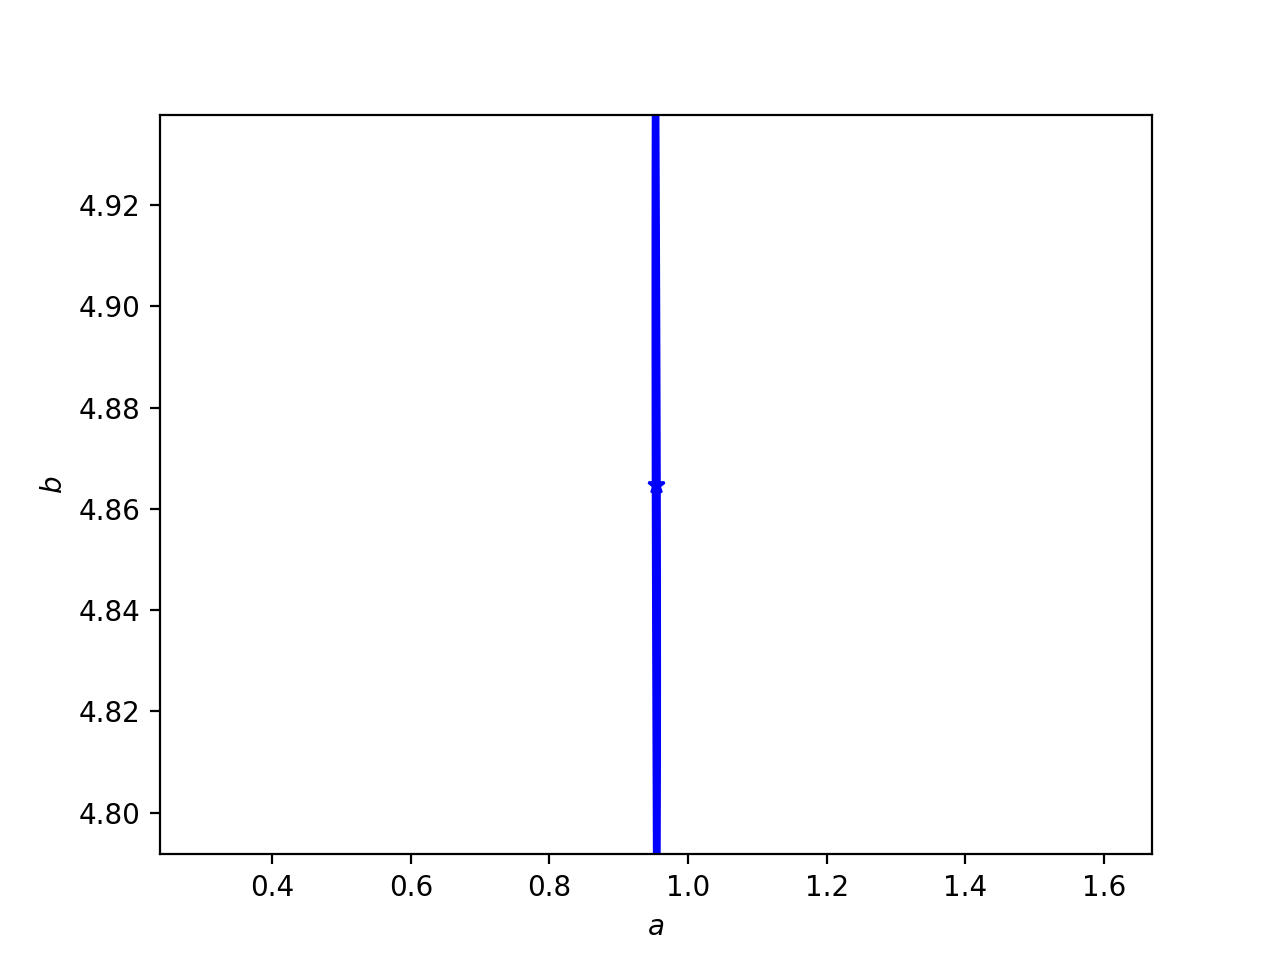

In [13]:
tv = np.copy(res.x)
print(tv)
n = 30
xvals = np.zeros((n+1,n+1))
yvals = np.zeros((n+1,n+1))
pvals = np.zeros((n+1,n+1))

for i1 in range(n+1):
    tv[1] = res.x[1]*(1+0.5/n*(i1-n/2))
    for i0 in range(n+1):
        tv[0] = res.x[0]*(1+0.5/n*(i0-n/2))
        xvals[i0,i1] = tv[0]
        yvals[i0,i1] = tv[1]
        pvals[i0,i1] = llfun(tv,loud=False) - res.fun
    #
#
fig, ax = plt.subplots()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$b$")

ndf = len(lM) - 2
sigma = np.sqrt(ndf)
ax.contour(xvals,yvals,pvals,levels=[1*sigma,2*sigma],colors="b")
ax.plot([res.x[0]],[res.x[1]],"b*")

tv = np.copy(res.x)

for i1 in range(n+1):
    tv[1] = res.x[1]*(1+0.03/n*(i1-n/2))
    for i0 in range(n+1):
        tv[0] = res.x[0]*(1+1.5/n*(i0-n/2))
        xvals[i0,i1] = tv[0]
        yvals[i0,i1] = tv[1]
        pvals[i0,i1] = llfun(tv,loud = False) - res.fun
    #
#

fig, ax = plt.subplots()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$b$")

ax.contour(xvals,yvals,pvals,levels=[1*sigma,2*sigma],colors="b")
ax.plot([res.x[0]],[res.x[1]],"b*")

<IPython.core.display.Javascript object>


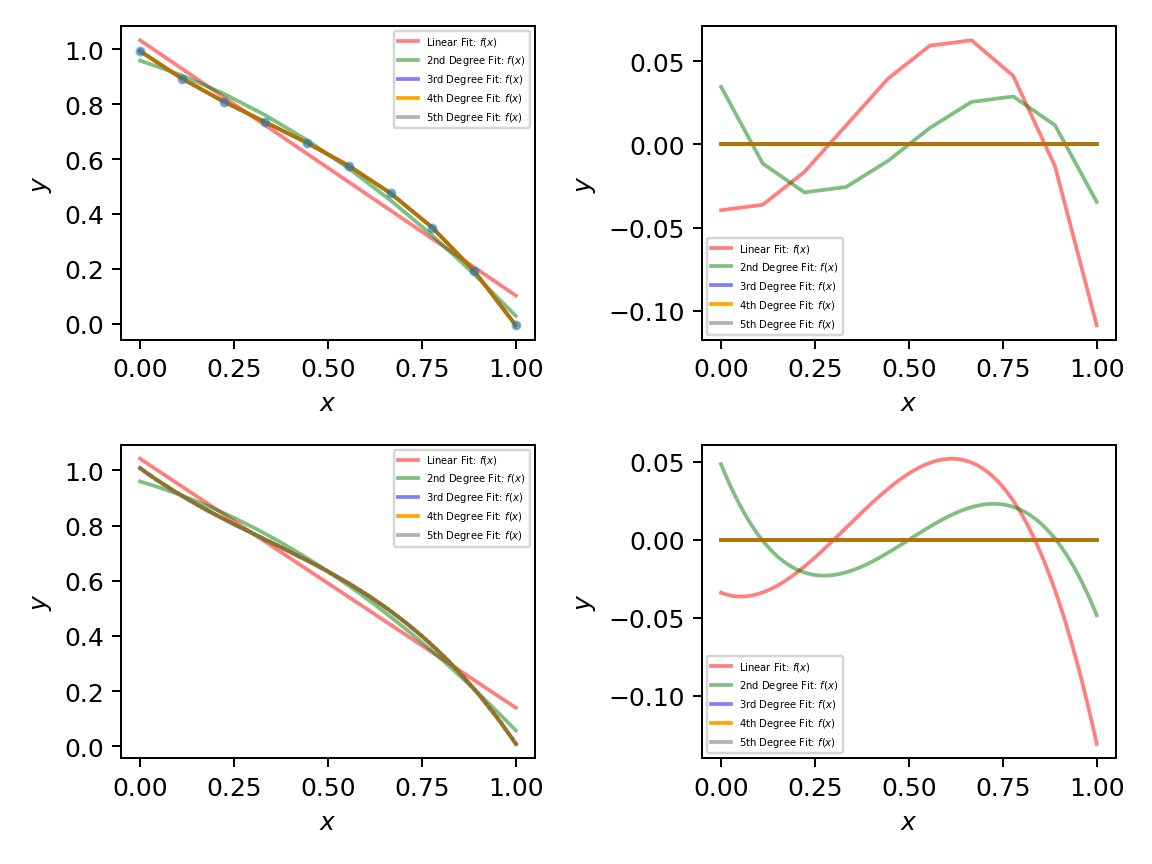

Converged with chi-squared 0.06
Converged with P-Value 0.9999999652
Number of degrees of freedom, dof = 8.00
Reduced chi-squared 0.01

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 1.033e+00                | 3.838e-01               
1           | 0.000e+00                | -9.309e-01               | 6.470e-01               
Converged with chi-squared 0.01
Converged with P-Value 0.9999999978
Number of degrees of freedom, dof = 7.00
Reduced chi-squared 0.00

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 9.589e-01                | 5.134e-01               
1           | 0.000e+00                | -4.309e-01               | 2.391e+00               
2           | 0.000e+00                | -5.000e-01               | 2.302e+00               
Converged with chi-squared 0.00
Converged with P-Valu

In [48]:
# Problem # 2
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy import optimize
from scipy import stats
import random

def linear(p, xvar):
    return p[0] + p[1]*xvar
def residual(p,func, xvar, yvar, err):
    return (func(p, xvar) - yvar)/err
def data_fit(p0,func,xvar, yvar, err, tmi=0):
    try:
        fit = optimize.least_squares(residual, p0, args = (func, xvar, yvar, err),verbose=tmi)
    except Exception as error:
        print("Something has gone wrong:",error)
        return p0,np.zeros_like(p0),np.nan,np.nan
    pf = fit['x']

    try:
        cov = np.linalg.inv(fit['jac'].T.dot(fit['jac']))          
    except:
        return pf,np.zeros_like(pf),np.nan,np.nan
    chisq = sum(residual(pf,func,xvar, yvar, err) **2)
    dof = len(xvar) - len(pf)
    red_chisq = chisq/dof
    pferr = np.sqrt(np.diagonal(cov))
    # finds the uncertainty in fit parameters by squaring diagonal elements of the covariance matrix
    p_val = 1 - scipy.stats.chi2.cdf(chisq, dof)
    print('Converged with chi-squared {:.2f}'.format(chisq))
    print('Converged with P-Value {:.10f}'.format(p_val))
    print('Number of degrees of freedom, dof = {:.2f}'.format(dof))
    print('Reduced chi-squared {:.2f}'.format(red_chisq))
    print()
    Columns = ["Parameter #","Initial guess values:", "Best fit values:", "Uncertainties in the best fit values:"]
    print('{:<11}'.format(Columns[0]),'|','{:<24}'.format(Columns[1]),"|",'{:<24}'.format(Columns[2]),"|",'{:<24}'.format(Columns[3]))
    for num in range(len(pf)):
        print('{:<11}'.format(num),'|','{:<24.3e}'.format(p0[num]),'|','{:<24.3e}'.format(pf[num]),'|','{:<24.3e}'.format(pferr[num]))
    return pf, pferr, chisq, dof
def linear(p, xvar):
    return p[0] + p[1]*xvar
def second(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2)
def third(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3)
def fourth(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3) + p[4]*(xvar **4)
def fifth(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3) + p[4]*(xvar **4) + p[5]*(xvar **5)
def arr(m):
    x = np.linspace(0, 1, num = m)
    return x
def yt(xvar):
    return 1 - xvar + (xvar ** 2) - (xvar ** 3)
def noise(x):
    yt1 = yt(x)
    w = random.gauss(0, 1)
    y = yt1 + 0.01 * w
    return y,w
def residual1(p,func, xvar, yvar):
    return yvar - func(p, xvar)

fig, axx = plt.subplots(nrows = 2,ncols = 2)

x10 = arr(10)
xx = noise(x10)
y10 = xx[0]

pf1, perr1, chisq1, dof1 = data_fit([0,0],linear, x10, y10, xx[1])
pf2, perr2, chisq2, dof2 = data_fit([0,0,0],second, x10, y10, xx[1])
pf3, perr3, chisq3, dof3 = data_fit([0,0,0,0],third, x10, y10, xx[1])
pf4, perr4, chisq4, dof4 = data_fit([0,0,0,0,0],fourth, x10, y10, xx[1])
pf5, perr5, chisq5, dof5 = data_fit([0,0,0,0,0,0],fifth, x10, y10, xx[1])

axx[0][0].plot(x10, linear(pf1, x10), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[0][0].plot(x10, second(pf2, x10), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[0][0].plot(x10, third(pf3, x10), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[0][0].plot(x10, fourth(pf4, x10), 'orange', label = '4th Degree Fit: $f(x)$')
axx[0][0].plot(x10, fifth(pf5, x10), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[0][0].plot(x10, y10,'o', markersize=3,alpha = 0.5,)
axx[0][0].set_xlabel(r"$x$")
axx[0][0].set_ylabel(r"$y$")
axx[0][0].legend(fontsize = 4)

axx[0][1].plot(x10, residual1(pf1,linear, x10, xx[0]), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf2,second, x10, xx[0]), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf3,third, x10, xx[0]), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf4,fourth, x10, xx[0]), 'orange', label = '4th Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf5,fifth, x10, xx[0]), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[0][1].set_xlabel(r"$x$")
axx[0][1].set_ylabel(r"$y$")
axx[0][1].legend(fontsize = 4)

#AIC = 2k -2log(L)
#BIC = k*log(n) - 2log(L)
    # Maximized value of the likelihood function
    # N is number of data points in x
    # K the number of parameters

x100 = arr(100)
xx100 = noise(x100)
y100 = xx100[0]

pf1, perr1, chisq1, dof1 = data_fit([0,0],linear, x100, y100, xx100[1])
pf2, perr2, chisq2, dof2 = data_fit([0,0,0],second, x100, y100, xx100[1])
pf3, perr3, chisq3, dof3 = data_fit([0,0,0,0],third, x100, y100, xx100[1])
pf4, perr4, chisq4, dof4 = data_fit([0,0,0,0,0],fourth, x100, y100, xx100[1])
pf5, perr5, chisq5, dof5 = data_fit([0,0,0,0,0,0],fifth, x100, y100, xx100[1])

axx[1][0].plot(x100, linear(pf1, x100), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[1][0].plot(x100, second(pf2, x100), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[1][0].plot(x100, third(pf3, x100), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[1][0].plot(x100, fourth(pf4, x100), 'orange',label = '4th Degree Fit: $f(x)$')
axx[1][0].plot(x100, fifth(pf5, x100), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[1][0].plot(x100, y100,'o',markersize=1, alpha = 0.2)
axx[1][0].set_xlabel(r"$x$")
axx[1][0].set_ylabel(r"$y$")
axx[1][0].legend(fontsize = 4)

axx[1][1].plot(x100, residual1(pf1,linear, x100, xx100[0]), 'red', alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf2,second, x100, xx100[0]), 'green', alpha = 0.5,label = '2nd Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf3,third, x100, xx100[0]), 'blue', alpha = 0.5,label = '3rd Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf4,fourth, x100, xx100[0]), 'orange', label = '4th Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf5,fifth, x100, xx100[0]), 'black', alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[1][1].set_xlabel(r"$x$")
axx[1][1].set_ylabel(r"$y$")
axx[1][1].legend(fontsize = 4)
fig.tight_layout()

In [56]:
# Residuals for M = 10
fig, axx = plt.subplots(nrows = 3,ncols = 2)
axx[0][0].plot(x10, residual1(pf1,linear, x10, xx[0]), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[1][0].plot(x10, residual1(pf2,second, x10, xx[0]), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf3,third, x10, xx[0]), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[1][1].plot(x10, residual1(pf4,fourth, x10, xx[0]), 'orange', label = '4th Degree Fit: $f(x)$')
axx[2][0].plot(x10, residual1(pf5,fifth, x10, xx[0]), marker = '.' ,'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[0][1].set_xlabel(r"$x$")
axx[0][1].set_ylabel(r"$y$")
axx[0][1].legend(fontsize = 5)
fig.tight_layout()

SyntaxError: positional argument follows keyword argument (3653091620.py, line 7)